<a href="https://colab.research.google.com/github/archakrishnan7/MINI-PROJECT/blob/main/Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import time
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
attack_data = pd.read_csv("/content/attacks.csv",encoding = "latin1")
out_dir = "outputs"
intervel_seconds = 20
max_runs = 3

In [3]:
attack_data.isnull().sum()

,0
Case Number,19519
Date,19520
Year,19522
Type,19524
Country,19566
Area,19932
Location,20031
Activity,20055
Name,19726
Sex,20097


In [4]:
import pandas as pd
import os

def extract():
    attack_data = pd.read_csv('/content/attacks.csv', encoding='latin1')
    print(f"Extracted {len(attack_data)} rows")
    return attack_data


def transform(attack_data):

    attack_data = attack_data.drop_duplicates().copy()

    print(attack_data.isnull().sum())


    attack_data['Year'] = pd.to_numeric(attack_data['Year'], errors='coerce')
    attack_data['Age'] = pd.to_numeric(attack_data['Age'], errors='coerce')

    numeric_cols = attack_data.select_dtypes(include='number').columns

    for col in numeric_cols:
        attack_data[col] = attack_data[col].fillna(attack_data[col].median())


    text_cols = attack_data.select_dtypes(include='object').columns
    attack_data[text_cols] = attack_data[text_cols].fillna("Unknown")


    attack_data['Case Number'] = pd.to_datetime(attack_data['Case Number'],errors='coerce')

    attack_data['Date'] = pd.to_datetime(attack_data['Date'],errors='coerce')

    datetime_cols = ['Case Number', 'Date']

    for col in datetime_cols:
        attack_data[col] = attack_data[col].fillna(
            attack_data[col].median()
        )

    cols_to_drop = ['Case Number.1','Case Number.2','pdf','href formula','href']

    attack_data = attack_data.drop(columns=cols_to_drop, errors='ignore')

    return attack_data


def load(attack_data):

    os.makedirs(out_dir, exist_ok=True)

    output_path = f"{out_dir}attacks.csv"

    attack_data.to_csv(output_path, index=False)

    print(f"Loaded {len(attack_data)} rows")
    print(f"Saved transformed data to: {output_path}")

In [5]:
attack_data = extract()
attack_data = transform(attack_data)
load(attack_data)

Extracted 25614 rows
Case Number                  2
Date                         3
Year                         5
Type                         7
Country                     49
Area                       415
Location                   514
Activity                   538
Name                       209
Sex                        580
Age                       2723
Injury                      31
Fatal (Y/N)                 33
Time                      3249
Species                   2997
Investigator or Source      20
pdf                          3
href formula                 4
href                         4
Case Number.1                3
Case Number.2                3
original order               3
dtype: int64
Loaded 6097 rows
Saved transformed data to: outputsattacks.csv


In [6]:
attack_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6097 entries, 0 to 25613
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Case Number             6097 non-null   datetime64[ns]
 1   Date                    6097 non-null   datetime64[ns]
 2   Year                    6097 non-null   float64       
 3   Type                    6097 non-null   object        
 4   Country                 6097 non-null   object        
 5   Area                    6097 non-null   object        
 6   Location                6097 non-null   object        
 7   Activity                6097 non-null   object        
 8   Name                    6097 non-null   object        
 9   Sex                     6097 non-null   object        
 10  Age                     6097 non-null   float64       
 11  Injury                  6097 non-null   object        
 12  Fatal (Y/N)             6097 non-null   object      

In [7]:
attack_data.isnull().sum()

,0
Case Number,0
Date,0
Year,0
Type,0
Country,0
Area,0
Location,0
Activity,0
Name,0
Sex,0


In [8]:
attack_data.shape

(6097, 17)

Outliers.

In [9]:
numeric_cols = attack_data.select_dtypes(include='number').columns


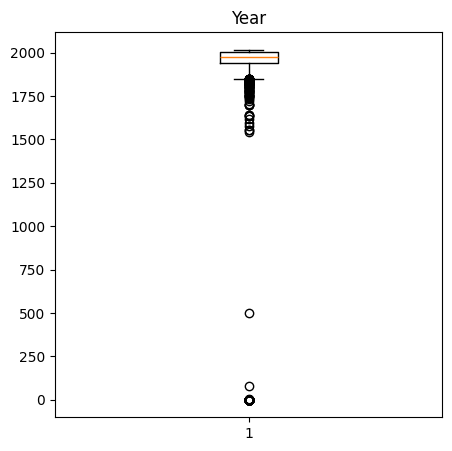

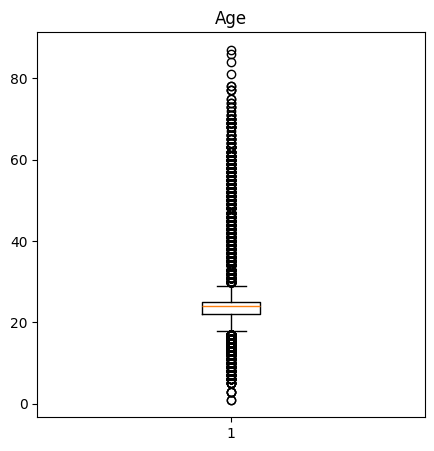

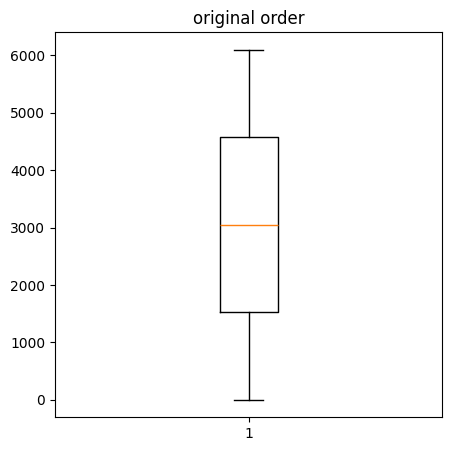

In [10]:
for i in numeric_cols:
  plt.figure(figsize=(5,5))
  plt.boxplot(attack_data[i])
  plt.title(i)

In [11]:
columns = ['Year','Age']
for col in columns:
   Q1 = attack_data[col].quantile(0.25)
   Q3 = attack_data[col].quantile(0.75)
   IQR = Q3 - Q1
   lower = Q1 - 1.5 * IQR
   upper = Q3 + 1.5 * IQR
   attack_data = attack_data[(attack_data[col] >= lower) &(attack_data[col] <= upper)]
   print(Q1,Q3,IQR,lower,upper)

1942.0 2004.0 62.0 1849.0 2097.0
22.0 25.0 3.0 17.5 29.5


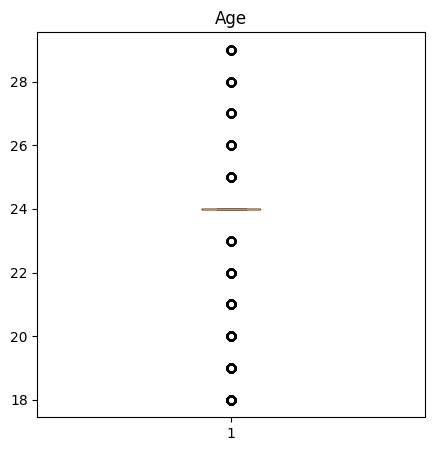

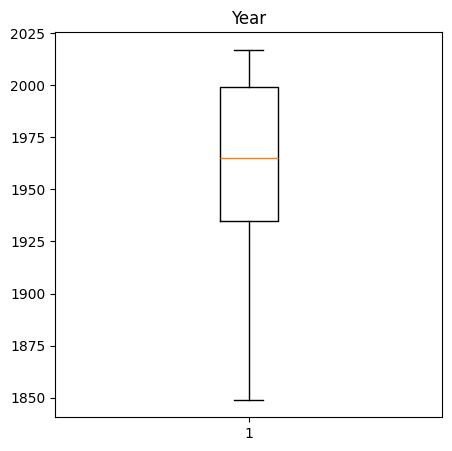

In [12]:
for col in ['Age', 'Year']:
    plt.figure(figsize=(5,5))
    plt.boxplot(attack_data[col].dropna())
    plt.title(col)
    plt.show()

Encoding.

In [13]:
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,OneHotEncoder,StandardScaler

In [14]:
label_enc = LabelEncoder()
attack_data['Type'] = label_enc.fit_transform(attack_data['Type'])
attack_data


,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,Age,Injury,Fatal (Y/N),Time,Species,Investigator or Source,original order
1,1982-02-28,2017-06-10 00:00:00,2017.0,6,AUSTRALIA,Victoria,"Flinders, Mornington Penisula",Surfing,female,F,24.0,"No injury, knocke off board",N,15h45,7 gill shark,Unknown,6094.0
2,1982-02-28,2017-06-10 00:00:00,2017.0,6,USA,Florida,"Ponce Inlet, Volusia County",Surfing,Bryan Brock,M,19.0,Laceration to left foot,N,10h00,Unknown,"Daytona Beach News-Journal, 6/10/2017",6093.0
4,2017-06-04,2017-06-04 00:00:00,2017.0,6,USA,Florida,"Middle Sambo Reef off Boca Chica, Monroe County",Spearfishing,Parker Simpson,M,24.0,Laceration to shin,N,Unknown,8' shark,"Nine News, 6/7/2017",6091.0
6,2017-05-30,2017-05-30 00:00:00,2017.0,3,USA,South Carolina,"Awendaw, Charleston County",Touching a shark,Mackenzie Higgins,F,20.0,Right hand bitten by hooked shark PROVOKED INC...,N,Unknown,3' shark,"C. Creswell, GSAF",6089.0
7,2017-05-28,2017-05-28 00:00:00,2017.0,6,USA,Florida,Off Jupiter,Feeding sharks,Randy Jordan,M,24.0,Lacerations to right arm,N,Morning,Tiger shark,"M. Michaelson, GSAF",6088.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5885,1982-02-28,1994-01-31 12:00:00,1976.0,6,ENGLAND,Cumberland,Whitehaven,Swimming,a boy,M,24.0,FATAL,Unknown,Unknown,Unknown,"C. Moore, GSAF",210.0
5923,1806-04-24,1994-01-31 12:00:00,1896.0,5,USA,Unknown,Unknown,Sea Disaster,Crew of the schooner Mary,Unknown,24.0,Shark scavenged on the dead sailors,Unknown,Unknown,Unknown,"Evening Post, 9/6/1806",172.0
6094,1982-02-28,1994-01-31 12:00:00,1976.0,5,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,24.0,Unknown,Unknown,Unknown,Unknown,Unknown,3048.5
6101,1982-02-28,1994-01-31 12:00:00,1976.0,5,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,24.0,Unknown,Unknown,Unknown,N,Unknown,3048.5


In [15]:
freq = attack_data['Country'].value_counts() / len(attack_data)

attack_data['Country'] = attack_data['Country'].map(freq)
attack_data.head()

,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,Age,Injury,Fatal (Y/N),Time,Species,Investigator or Source,original order
1,1982-02-28,2017-06-10,2017.0,6,0.221126,Victoria,"Flinders, Mornington Penisula",Surfing,female,F,24.0,"No injury, knocke off board",N,15h45,7 gill shark,Unknown,6094.0
2,1982-02-28,2017-06-10,2017.0,6,0.310148,Florida,"Ponce Inlet, Volusia County",Surfing,Bryan Brock,M,19.0,Laceration to left foot,N,10h00,Unknown,"Daytona Beach News-Journal, 6/10/2017",6093.0
4,2017-06-04,2017-06-04,2017.0,6,0.310148,Florida,"Middle Sambo Reef off Boca Chica, Monroe County",Spearfishing,Parker Simpson,M,24.0,Laceration to shin,N,Unknown,8' shark,"Nine News, 6/7/2017",6091.0
6,2017-05-30,2017-05-30,2017.0,3,0.310148,South Carolina,"Awendaw, Charleston County",Touching a shark,Mackenzie Higgins,F,20.0,Right hand bitten by hooked shark PROVOKED INC...,N,Unknown,3' shark,"C. Creswell, GSAF",6089.0
7,2017-05-28,2017-05-28,2017.0,6,0.310148,Florida,Off Jupiter,Feeding sharks,Randy Jordan,M,24.0,Lacerations to right arm,N,Morning,Tiger shark,"M. Michaelson, GSAF",6088.0


In [16]:
freq = attack_data['Area'].value_counts() / len(attack_data)

attack_data['Area'] = attack_data['Area'].map(freq)
attack_data.head()

,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,Age,Injury,Fatal (Y/N),Time,Species,Investigator or Source,original order
1,1982-02-28,2017-06-10,2017.0,6,0.221126,0.015313,"Flinders, Mornington Penisula",Surfing,female,F,24.0,"No injury, knocke off board",N,15h45,7 gill shark,Unknown,6094.0
2,1982-02-28,2017-06-10,2017.0,6,0.310148,0.136777,"Ponce Inlet, Volusia County",Surfing,Bryan Brock,M,19.0,Laceration to left foot,N,10h00,Unknown,"Daytona Beach News-Journal, 6/10/2017",6093.0
4,2017-06-04,2017-06-04,2017.0,6,0.310148,0.136777,"Middle Sambo Reef off Boca Chica, Monroe County",Spearfishing,Parker Simpson,M,24.0,Laceration to shin,N,Unknown,8' shark,"Nine News, 6/7/2017",6091.0
6,2017-05-30,2017-05-30,2017.0,3,0.310148,0.018946,"Awendaw, Charleston County",Touching a shark,Mackenzie Higgins,F,20.0,Right hand bitten by hooked shark PROVOKED INC...,N,Unknown,3' shark,"C. Creswell, GSAF",6089.0
7,2017-05-28,2017-05-28,2017.0,6,0.310148,0.136777,Off Jupiter,Feeding sharks,Randy Jordan,M,24.0,Lacerations to right arm,N,Morning,Tiger shark,"M. Michaelson, GSAF",6088.0


In [17]:
attack_data = attack_data.drop('Investigator or Source',axis=1)

In [18]:
attack_data.columns

Index(['Case Number', 'Date', 'Year', 'Type', 'Country', 'Area', 'Location',
       'Activity', 'Name', 'Sex ', 'Age', 'Injury', 'Fatal (Y/N)', 'Time',
       'Species ', 'original order'],
      dtype='object')

In [19]:
freq = attack_data['Location'].value_counts() / len(attack_data)

attack_data['Location'] = attack_data['Location'].map(freq)
attack_data.head()

,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,Age,Injury,Fatal (Y/N),Time,Species,original order
1,1982-02-28,2017-06-10,2017.0,6,0.221126,0.015313,0.000519,Surfing,female,F,24.0,"No injury, knocke off board",N,15h45,7 gill shark,6094.0
2,1982-02-28,2017-06-10,2017.0,6,0.310148,0.136777,0.002076,Surfing,Bryan Brock,M,19.0,Laceration to left foot,N,10h00,Unknown,6093.0
4,2017-06-04,2017-06-04,2017.0,6,0.310148,0.136777,0.000260,Spearfishing,Parker Simpson,M,24.0,Laceration to shin,N,Unknown,8' shark,6091.0
6,2017-05-30,2017-05-30,2017.0,3,0.310148,0.018946,0.000260,Touching a shark,Mackenzie Higgins,F,20.0,Right hand bitten by hooked shark PROVOKED INC...,N,Unknown,3' shark,6089.0
7,2017-05-28,2017-05-28,2017.0,6,0.310148,0.136777,0.000260,Feeding sharks,Randy Jordan,M,24.0,Lacerations to right arm,N,Morning,Tiger shark,6088.0


In [20]:
# Clean first
attack_data['Activity'] = attack_data['Activity'].fillna('Unknown')
attack_data['Activity'] = attack_data['Activity'].str.strip().str.lower()

# Create frequency dictionary AFTER cleaning
freq = attack_data['Activity'].value_counts(normalize=True)

# Encode
attack_data['Activity'] = attack_data['Activity'].map(freq)

In [21]:
attack_data.head()

,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,Age,Injury,Fatal (Y/N),Time,Species,original order
1,1982-02-28,2017-06-10,2017.0,6,0.221126,0.015313,0.000519,0.135998,female,F,24.0,"No injury, knocke off board",N,15h45,7 gill shark,6094.0
2,1982-02-28,2017-06-10,2017.0,6,0.310148,0.136777,0.002076,0.135998,Bryan Brock,M,19.0,Laceration to left foot,N,10h00,Unknown,6093.0
4,2017-06-04,2017-06-04,2017.0,6,0.310148,0.136777,0.000260,0.057877,Parker Simpson,M,24.0,Laceration to shin,N,Unknown,8' shark,6091.0
6,2017-05-30,2017-05-30,2017.0,3,0.310148,0.018946,0.000260,0.000260,Mackenzie Higgins,F,20.0,Right hand bitten by hooked shark PROVOKED INC...,N,Unknown,3' shark,6089.0
7,2017-05-28,2017-05-28,2017.0,6,0.310148,0.136777,0.000260,0.000260,Randy Jordan,M,24.0,Lacerations to right arm,N,Morning,Tiger shark,6088.0


In [22]:
label_enc = LabelEncoder()
attack_data['Sex '] = label_enc.fit_transform(attack_data['Sex '])
attack_data


,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,Age,Injury,Fatal (Y/N),Time,Species,original order
1,1982-02-28,2017-06-10 00:00:00,2017.0,6,0.221126,0.015313,0.000519,0.135998,female,1,24.0,"No injury, knocke off board",N,15h45,7 gill shark,6094.0
2,1982-02-28,2017-06-10 00:00:00,2017.0,6,0.310148,0.136777,0.002076,0.135998,Bryan Brock,2,19.0,Laceration to left foot,N,10h00,Unknown,6093.0
4,2017-06-04,2017-06-04 00:00:00,2017.0,6,0.310148,0.136777,0.000260,0.057877,Parker Simpson,2,24.0,Laceration to shin,N,Unknown,8' shark,6091.0
6,2017-05-30,2017-05-30 00:00:00,2017.0,3,0.310148,0.018946,0.000260,0.000260,Mackenzie Higgins,1,20.0,Right hand bitten by hooked shark PROVOKED INC...,N,Unknown,3' shark,6089.0
7,2017-05-28,2017-05-28 00:00:00,2017.0,6,0.310148,0.136777,0.000260,0.000260,Randy Jordan,2,24.0,Lacerations to right arm,N,Morning,Tiger shark,6088.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5885,1982-02-28,1994-01-31 12:00:00,1976.0,6,0.003634,0.000260,0.000260,0.124059,a boy,2,24.0,FATAL,Unknown,Unknown,Unknown,210.0
5923,1806-04-24,1994-01-31 12:00:00,1896.0,5,0.310148,0.075006,0.093434,0.002855,Crew of the schooner Mary,5,24.0,Shark scavenged on the dead sailors,Unknown,Unknown,Unknown,172.0
6094,1982-02-28,1994-01-31 12:00:00,1976.0,5,0.008824,0.075006,0.093434,0.105892,Unknown,5,24.0,Unknown,Unknown,Unknown,Unknown,3048.5
6101,1982-02-28,1994-01-31 12:00:00,1976.0,5,0.008824,0.075006,0.093434,0.105892,Unknown,5,24.0,Unknown,Unknown,Unknown,N,3048.5


In [23]:
label_enc = LabelEncoder()
attack_data['Fatal (Y/N)'] = label_enc.fit_transform(attack_data['Fatal (Y/N)'])
attack_data.head()


,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,Age,Injury,Fatal (Y/N),Time,Species,original order
1,1982-02-28,2017-06-10,2017.0,6,0.221126,0.015313,0.000519,0.135998,female,1,24.0,"No injury, knocke off board",3,15h45,7 gill shark,6094.0
2,1982-02-28,2017-06-10,2017.0,6,0.310148,0.136777,0.002076,0.135998,Bryan Brock,2,19.0,Laceration to left foot,3,10h00,Unknown,6093.0
4,2017-06-04,2017-06-04,2017.0,6,0.310148,0.136777,0.000260,0.057877,Parker Simpson,2,24.0,Laceration to shin,3,Unknown,8' shark,6091.0
6,2017-05-30,2017-05-30,2017.0,3,0.310148,0.018946,0.000260,0.000260,Mackenzie Higgins,1,20.0,Right hand bitten by hooked shark PROVOKED INC...,3,Unknown,3' shark,6089.0
7,2017-05-28,2017-05-28,2017.0,6,0.310148,0.136777,0.000260,0.000260,Randy Jordan,2,24.0,Lacerations to right arm,3,Morning,Tiger shark,6088.0


In [24]:
freq = attack_data['Species '].value_counts() / len(attack_data)

attack_data['Species '] = attack_data['Species '].map(freq)
attack_data.head()

,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,Age,Injury,Fatal (Y/N),Time,Species,original order
1,1982-02-28,2017-06-10,2017.0,6,0.221126,0.015313,0.000519,0.135998,female,1,24.0,"No injury, knocke off board",3,15h45,0.000260,6094.0
2,1982-02-28,2017-06-10,2017.0,6,0.310148,0.136777,0.002076,0.135998,Bryan Brock,2,19.0,Laceration to left foot,3,10h00,0.520374,6093.0
4,2017-06-04,2017-06-04,2017.0,6,0.310148,0.136777,0.000260,0.057877,Parker Simpson,2,24.0,Laceration to shin,3,Unknown,0.001298,6091.0
6,2017-05-30,2017-05-30,2017.0,3,0.310148,0.018946,0.000260,0.000260,Mackenzie Higgins,1,20.0,Right hand bitten by hooked shark PROVOKED INC...,3,Unknown,0.004153,6089.0
7,2017-05-28,2017-05-28,2017.0,6,0.310148,0.136777,0.000260,0.000260,Randy Jordan,2,24.0,Lacerations to right arm,3,Morning,0.010901,6088.0


Test and Training.

In [25]:
y = attack_data['Fatal (Y/N)']

x = attack_data.drop(columns=['Fatal (Y/N)', 'Case Number', 'Name','Injury','Time','original order','Date'])

In [26]:
x.columns

Index(['Year', 'Type', 'Country', 'Area', 'Location', 'Activity', 'Sex ',
       'Age', 'Species '],
      dtype='object')

In [27]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [28]:
x_train.shape

(3082, 9)

In [29]:
x_test.shape

(771, 9)

In [30]:
y_train.shape

(3082,)

In [31]:
y_test.shape

(771,)

In [32]:
std_scalar = StandardScaler()

cols_to_scale = ['Year','Type','Country','Area', 'Location', 'Activity', 'Sex ', 'Age', 'Species ']

x_train[cols_to_scale] = std_scalar.fit_transform(x_train[cols_to_scale])

x_test[cols_to_scale] = std_scalar.transform(x_test[cols_to_scale])


x_train.head()


,Year,Type,Country,Area,Location,Activity,Sex,Age,Species
3747,-0.016245,-0.955231,0.477112,0.186298,-0.341197,-0.975445,2.427226,0.197028,-1.039497
3535,0.055968,-2.549466,-1.037615,-0.905271,-0.341197,-0.989438,2.427226,0.197028,0.972324
2920,0.441107,0.639004,1.169846,-0.939742,-0.341197,-0.816852,-1.218344,-0.786356,-1.039497
4386,-0.305100,0.639004,-1.225441,-0.951232,-0.341197,1.193547,-0.306952,0.197028,0.972324
1476,1.042887,-0.955231,0.477112,-0.629506,-0.341197,-1.031419,2.427226,0.197028,-1.039497
